In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

In [2]:
# ===== Config =====
import os
import urllib.request

DATA_URL = "https://raw.githubusercontent.com/<your-username>/cusat-summer-internship-ml/main/data/student-mat.csv"
DATA_PATH = "student-mat.csv"

if not os.path.exists(DATA_PATH):
    urllib.request.urlretrieve(DATA_URL, DATA_PATH)

In [3]:
# ===== 1. Dataset Preparation =====
df = pd.read_csv(DATA_PATH, sep=';')

features = ['studytime', 'failures', 'absences', 'G1', 'G2']
target = 'G3'

X = df[features].values
y = df[target].values.reshape(-1, 1)  # column vector

print(f"Dataset shape: {df.shape}")
print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

print("First 5 rows of features:")
print(pd.DataFrame(X, columns=features).head())
print("First 5 rows of target:")
print(pd.DataFrame(y, columns=[target]).head())

Dataset shape: (395, 33)
Features (X) shape: (395, 5)
Target (y) shape: (395, 1)
First 5 rows of features:
   studytime  failures  absences  G1  G2
0          2         0         6   5   6
1          2         0         4   5   5
2          2         3        10   7   8
3          3         0         2  15  14
4          2         0         4   6  10
First 5 rows of target:
   G3
0   6
1   6
2  10
3  15
4  10


In [4]:
# ===== 2. Data Preprocessing =====
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

# Standardize features and target separately
x_scaler = StandardScaler()
X_train_scaled = x_scaler.fit_transform(X_train)
X_test_scaled = x_scaler.transform(X_test)

y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train)
y_test_scaled = y_scaler.transform(y_test)

print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"y_train_scaled shape: {y_train_scaled.shape}")

Training set size: 316 samples
Test set size: 79 samples
X_train_scaled shape: (316, 5)
y_train_scaled shape: (316, 1)


In [5]:
# ===== 3. MLP From Scratch Implementation =====
# --- Activation Functions ---
def relu(Z):
    """ReLU activation function."""
    return np.maximum(0, Z)

def relu_derivative(Z):
    """Derivative of ReLU activation function."""
    return (Z > 0).astype(float)

def linear(Z):
    """Linear activation function (identity) for output layer."""
    return Z

# --- Loss Function ---
def mean_squared_error_loss(y_true, y_pred):
    """Mean Squared Error loss function with 0.5 factor: L = 0.5 * (y_hat - y)^2."""
    return 0.5 * np.mean(np.square(y_pred - y_true))

# --- Parameter Initialization ---
def initialize_parameters(layer_sizes):
    """Initializes weights and biases for all layers."""
    parameters = {}
    L = len(layer_sizes)

    for l in range(1, L):
        if l < L - 1:  # Hidden layers: He initialization
            parameters[f'W{l}'] = np.random.randn(layer_sizes[l], layer_sizes[l-1]) * np.sqrt(2. / layer_sizes[l-1])
        else:  # Output layer: small random initialization
            parameters[f'W{l}'] = np.random.randn(layer_sizes[l], layer_sizes[l-1]) * 0.01
        parameters[f'b{l}'] = np.zeros((layer_sizes[l], 1))
    return parameters

# --- Forward Propagation ---
def forward_propagation(X_input, parameters, layer_sizes):
    """Performs forward propagation through the network."""
    caches = []
    A = X_input.T
    L = len(layer_sizes)

    for l in range(1, L):
        W = parameters[f'W{l}']
        b = parameters[f'b{l}']
        Z = np.dot(W, A) + b

        if l == L - 1:  # Output layer: linear
            A = linear(Z)
        else:  # Hidden layers: ReLU
            A = relu(Z)

        caches.append({'Z': Z, 'A': A})

    return A, caches

# --- Backward Propagation ---
def backward_propagation(y_pred_scaled, y_true_scaled, parameters, caches, layer_sizes, X_input):
    """Performs backward propagation to compute gradients."""
    grads = {}
    L = len(layer_sizes)
    m = y_true_scaled.shape[0]

    y_true_reshaped = y_true_scaled.T

    # Output layer gradients
    dZ = y_pred_scaled - y_true_reshaped

    if L == 2:
        A_prev_output_layer = X_input.T
    else:
        A_prev_output_layer = caches[L-3]['A']

    grads[f'dW{L-1}'] = (1 / m) * np.dot(dZ, A_prev_output_layer.T)
    grads[f'db{L-1}'] = (1 / m) * np.sum(dZ, axis=1, keepdims=True)

    # Hidden layer gradients
    for l_param_idx in reversed(range(1, L-1)):
        dZ = np.dot(parameters[f'W{l_param_idx + 1}'].T, dZ) * relu_derivative(caches[l_param_idx-1]['Z'])

        if l_param_idx == 1:
            A_prev_hidden_layer = X_input.T
        else:
            A_prev_hidden_layer = caches[l_param_idx-2]['A']

        grads[f'dW{l_param_idx}'] = (1 / m) * np.dot(dZ, A_prev_hidden_layer.T)
        grads[f'db{l_param_idx}'] = (1 / m) * np.sum(dZ, axis=1, keepdims=True)

    return grads

# --- Training Function ---
def train_mlp(X_train_scaled, y_train_scaled, layer_sizes, learning_rate, num_epochs):
    """Trains the MLP model using gradient descent."""
    parameters = initialize_parameters(layer_sizes)
    costs = []

    for epoch in range(1, num_epochs + 1):
        y_pred_scaled, caches = forward_propagation(X_train_scaled, parameters, layer_sizes)

        cost = mean_squared_error_loss(y_train_scaled, y_pred_scaled.T)
        costs.append(cost)

        grads = backward_propagation(y_pred_scaled, y_train_scaled, parameters, caches, layer_sizes, X_train_scaled)

        L = len(layer_sizes)
        for l in range(1, L):
            parameters[f'W{l}'] -= learning_rate * grads[f'dW{l}']
            parameters[f'b{l}'] -= learning_rate * grads[f'db{l}']

        if epoch % 100 == 0:
            print(f"Epoch {epoch}/{num_epochs}, Loss: {cost:.6f}")

    return parameters, costs

In [6]:
# ===== 4. Model Training =====
input_dim = X_train_scaled.shape[1]
output_dim = y_train_scaled.shape[1]
layer_sizes = [input_dim, 10, 5, output_dim]

learning_rate = 0.01
num_epochs = 2000

print(f"Training MLP with architecture: {layer_sizes}")
print(f"Learning Rate: {learning_rate}, Epochs: {num_epochs}")

parameters, costs = train_mlp(X_train_scaled, y_train_scaled, layer_sizes, learning_rate, num_epochs)

Training MLP with architecture: [5, 10, 5, 1]
Learning Rate: 0.01, Epochs: 2000
Epoch 100/2000, Loss: 0.299118
Epoch 200/2000, Loss: 0.218970
Epoch 300/2000, Loss: 0.180268
Epoch 400/2000, Loss: 0.159790
Epoch 500/2000, Loss: 0.147616
Epoch 600/2000, Loss: 0.139400
Epoch 700/2000, Loss: 0.132427
Epoch 800/2000, Loss: 0.126471
Epoch 900/2000, Loss: 0.121369
Epoch 1000/2000, Loss: 0.117107
Epoch 1100/2000, Loss: 0.113389
Epoch 1200/2000, Loss: 0.110053
Epoch 1300/2000, Loss: 0.107134
Epoch 1400/2000, Loss: 0.104569
Epoch 1500/2000, Loss: 0.102330
Epoch 1600/2000, Loss: 0.100299
Epoch 1700/2000, Loss: 0.098438
Epoch 1800/2000, Loss: 0.096713
Epoch 1900/2000, Loss: 0.095117
Epoch 2000/2000, Loss: 0.093632


In [7]:
# ===== 5. Model Evaluation =====
y_pred_test_scaled, _ = forward_propagation(X_test_scaled, parameters, layer_sizes)

y_pred_test = y_scaler.inverse_transform(y_pred_test_scaled.T)
y_test_original = y_scaler.inverse_transform(y_test_scaled)

y_pred_test = np.clip(y_pred_test, 0, 20)

mse = mean_squared_error(y_test_original, y_pred_test)
mae = mean_absolute_error(y_test_original, y_pred_test)

print(f"Mean Squared Error (MSE) on test set (original grade scale): {mse:.4f}")
print(f"Mean Absolute Error (MAE) on test set (original grade scale): {mae:.4f}")

Mean Squared Error (MSE) on test set (original grade scale): 4.8123
Mean Absolute Error (MAE) on test set (original grade scale): 1.5383


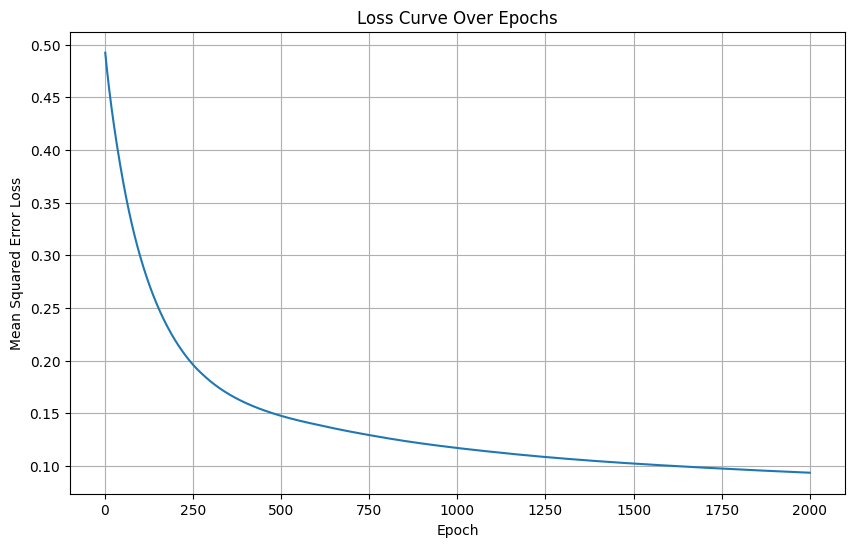

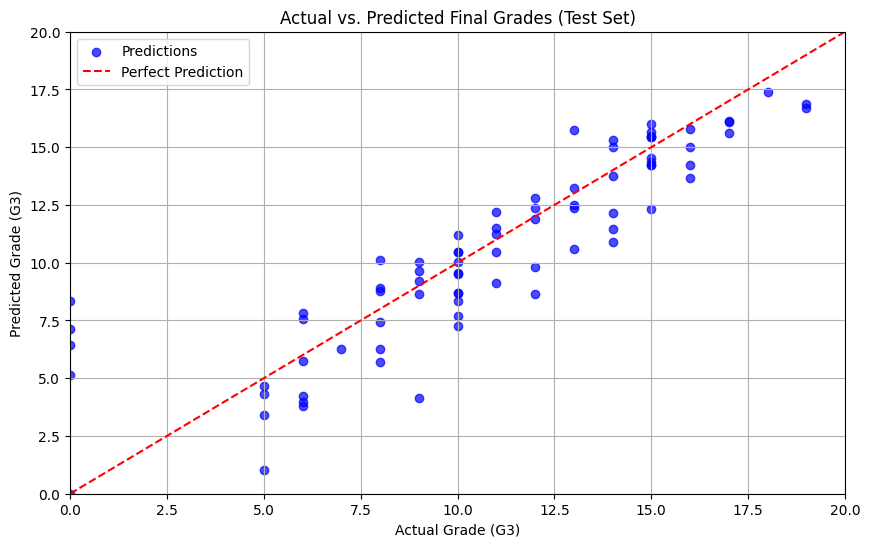

In [8]:
# ===== 6. Visualization =====
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(costs) + 1), costs)
plt.title('Loss Curve Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error Loss')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(y_test_original, y_pred_test, alpha=0.7, color='blue', label='Predictions')
plt.plot([0, 20], [0, 20], 'r--', label='Perfect Prediction')
plt.title('Actual vs. Predicted Final Grades (Test Set)')
plt.xlabel('Actual Grade (G3)')
plt.ylabel('Predicted Grade (G3)')
plt.xlim(0, 20)
plt.ylim(0, 20)
plt.grid(True)
plt.legend()
plt.show()

In [9]:
# ===== 7. TensorFlow/Keras Implementation =====
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()

# Same architecture as the scratch model: layer_sizes = [input_dim, 10, 5, output_dim]
keras_model = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(layer_sizes[1], activation='relu', name='hidden_layer_1'),
    layers.Dense(layer_sizes[2], activation='relu', name='hidden_layer_2'),
    layers.Dense(output_dim, activation='linear', name='output_layer')
])

keras_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
    loss='mse'
)

keras_model.summary()

print(f"Training Keras MLP with architecture: {layer_sizes}")
print(f"Learning Rate: {learning_rate}, Epochs: {num_epochs}")



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 10)             │            60 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121 (484.00 B)

 Trainable params: 121 (484.00 B)

 Non-trainable params: 0 (0.00 B)

Training Keras MLP with architecture: [5, 10, 5, 1]
Learning Rate: 0.01, Epochs: 2000


In [10]:
history = keras_model.fit(
    X_train_scaled,
    y_train_scaled,
    epochs=num_epochs,
    batch_size=32,
    verbose=0
)

y_pred_keras_scaled = keras_model.predict(X_test_scaled)

y_pred_keras = y_scaler.inverse_transform(y_pred_keras_scaled)
y_pred_keras = np.clip(y_pred_keras, 0, 20)

mse_keras = mean_squared_error(y_test_original, y_pred_keras)
mae_keras = mean_absolute_error(y_test_original, y_pred_keras)

print(f"Keras Mean Squared Error (MSE) on test set (original grade scale): {mse_keras:.4f}")
print(f"Keras Mean Absolute Error (MAE) on test set (original grade scale): {mae_keras:.4f}")

print(f"\nScratch MSE: {mse:.4f}, Keras MSE: {mse_keras:.4f}")
print(f"Scratch MAE: {mae:.4f}, Keras MAE: {mae_keras:.4f}")


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Keras Mean Squared Error (MSE) on test set (original grade scale): 5.1125
Keras Mean Absolute Error (MAE) on test set (original grade scale): 1.3642

Scratch MSE: 4.8123, Keras MSE: 5.1125
Scratch MAE: 1.5383, Keras MAE: 1.3642


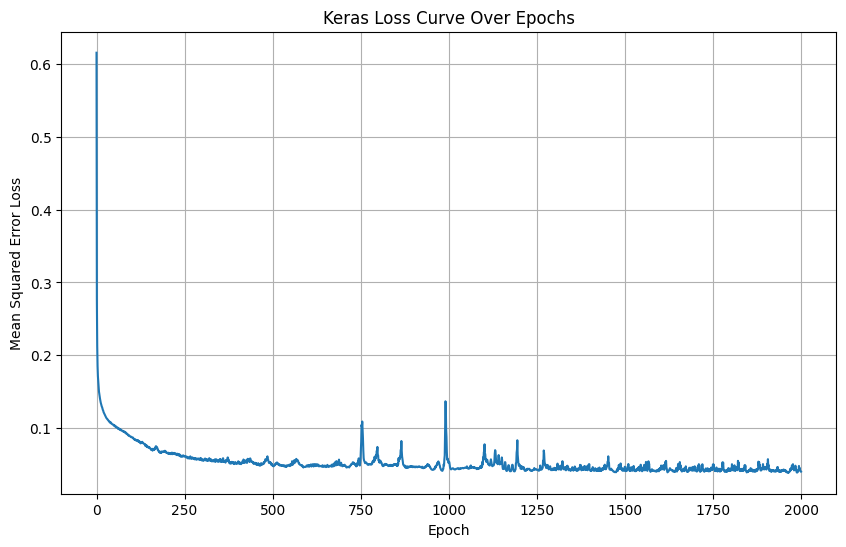

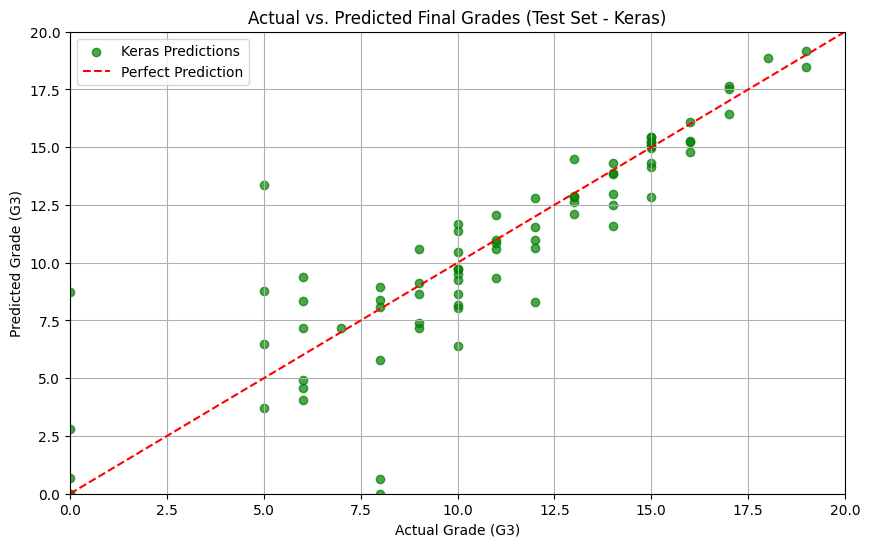

In [11]:
# Plot Keras Loss Curve
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'])
plt.title('Keras Loss Curve Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error Loss')
plt.grid(True)
plt.show()

# Plot Actual vs. Predicted Grades for Keras model
plt.figure(figsize=(10, 6))
plt.scatter(y_test_original, y_pred_keras, alpha=0.7, color='green', label='Keras Predictions')
plt.plot([0, 20], [0, 20], 'r--', label='Perfect Prediction')
plt.title('Actual vs. Predicted Final Grades (Test Set - Keras)')
plt.xlabel('Actual Grade (G3)')
plt.ylabel('Predicted Grade (G3)')
plt.xlim(0, 20)
plt.ylim(0, 20)
plt.grid(True)
plt.legend()
plt.show()